We will see Why traditional keyword-based movie recommendation is not enough, and how vector embeddings + vector stores can solve semantic similarity.

## Initial problem: building an IMDb-like website

Suppose you want to build a website containing information about every movie in the world.

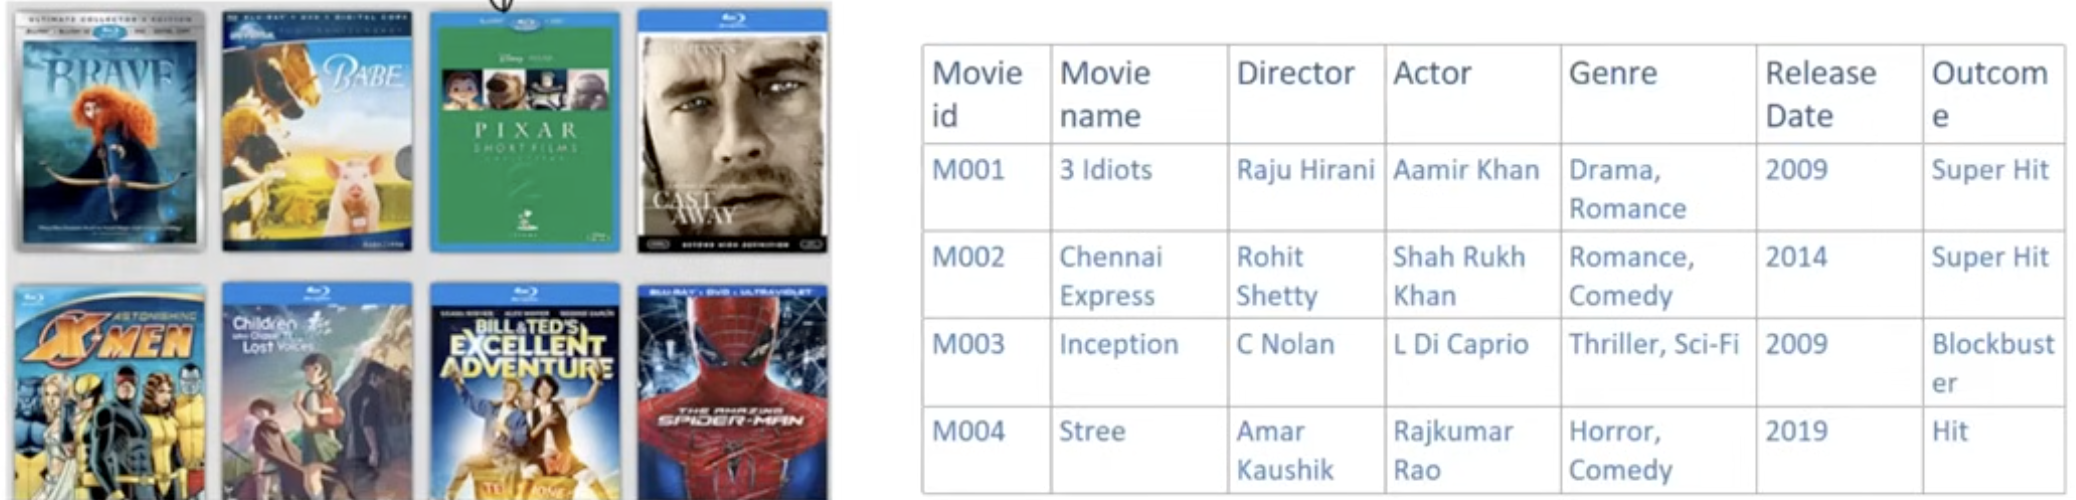

Architecture is basically: 

Movie Data -> Database -> python backend -> frontend -> movie website

The database stores structured information about movies.

## Where do we get all this movie data?

1. Public APIs : You can fetch movie information from an API.

Movie API -> Python -> Database

2. Web Scraping : You can scrape websites containing movie information.

Website -> Web Scraping -> Movie Data -> Database
   

Once you have the data, your Python backend can query the database and send the results to your frontend.

create a backend system from python that pulls data from database and send it to your front
end and your front end will display that data..

## Then we add a movie recommendation system



Suppose a user opens the page for: Spider-Man

You don't want your website to show only Spider-Man's information. You also want: "Movies similar to Spider-Man"

For example:

In [1]:
# Spider-Man
#     ↓
# Similar Movies
#     ├── Iron Man
#     ├── Avengers
#     ├── Batman
#     └── etc.

# This is a recommendation system.

## The first/simple approach: compare movie attributes (Keywords matching)

Suppose we represent a movie using attributes:

In [ ]:
# Movie
# ├── Director
# ├── Actor
# ├── Genre
# ├── Release Year
# └── etc.

For example:

Movie A:
- Actor = Aamir Khan
- Director = Rajkumar Hirani
- Genre = Drama, Comedy

and:

Movie B:
- Actor = Aamir Khan
- Director = Rajkumar Hirani
- Genre = Drama, Romance

We can compare these fields. If many attributes match:

1. Actor       → same
2. Director    → same
3. Genre       → similar

we might conclude: These movies are similar.This is a very basic content-based recommendation approach.

## But there is a major problem

 ## Problem 1: 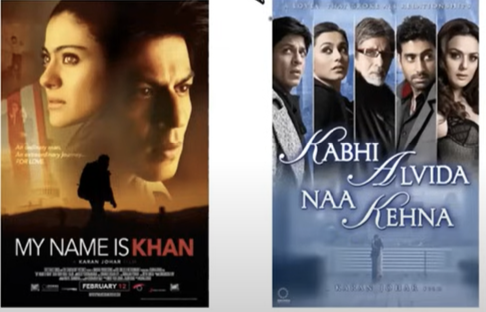

My Name Is Khan and Kabhi Alvida Naa Kehna, The system might consider them similar because they share things like:

- Actor
- Director
- Genre
- Keywords

But this doesn't necessarily mean the movies are semantically similar in the way a human would understand similarity. The system is essentially doing: Keyword/attribute matching rather than Meaning-based similarity

## Problem 2: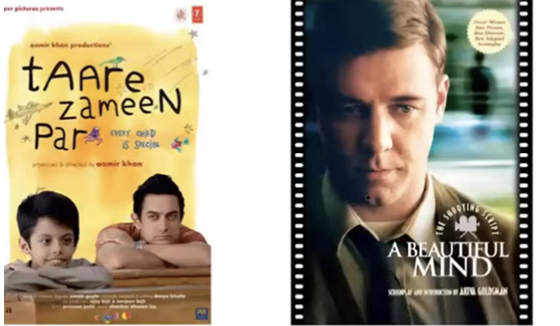

Taare Zameen Par and A Beautiful Mind, These movies can be considered very similar in terms of their themes/concepts:

- education
- human psychology
- exceptional individuals
- personal struggles
- overcoming challenges
- relationships
- mental/emotional development

But if you only compare explicit metadata/keywords, the system may say:

Taare Zameen Par <-> A Beautiful Mind


Keyword overlap → LOW, So the system might fail to recommend one when the other is actually a meaningful recommendation. This is the fundamental problem.

## Keyword matching vs semantic similarity

This is the most important concept in these notes.

Suppose you have:

Movie 1:"A child struggles with learning difficulties and receives help from an understanding teacher."


Movie 2:"A brilliant mathematician struggles with mental health and personal challenges."

The exact words aren't necessarily the same.

A keyword-based system might see:

Common words → very few

Similarity → LOW

But a human might understand:

Both involve:
- exceptional individuals
- personal struggles
- psychological challenges
- supportive relationships
- overcoming difficulties

Therefore:

Keyword similarity ≠ Semantic similarity

This is where embeddings become important.

To make the system better, just compare their plot/story instead of matching keywords

## You extract Plot:

Now you extract plot of every movie and store it in your database by web scraping or movie API

## What is an embedding?

An embedding converts text into a numerical vector that captures its semantic meaning.

For example:

In [ ]:
# "Movie about a child struggling in school"
#                     ↓
#             Embedding Model
#                     ↓
#        [0.21, -0.73, 0.44, 0.18, ...]

Another movie:


In [ ]:
# "Story of a brilliant person facing
# personal and psychological challenges"
#                     ↓
#             Embedding Model
#                     ↓
#        [0.19, -0.69, 0.41, 0.22, ...]

These vectors may be relatively close in vector space. Therefore: Semantic similarity → HIGH
even though the exact words are different

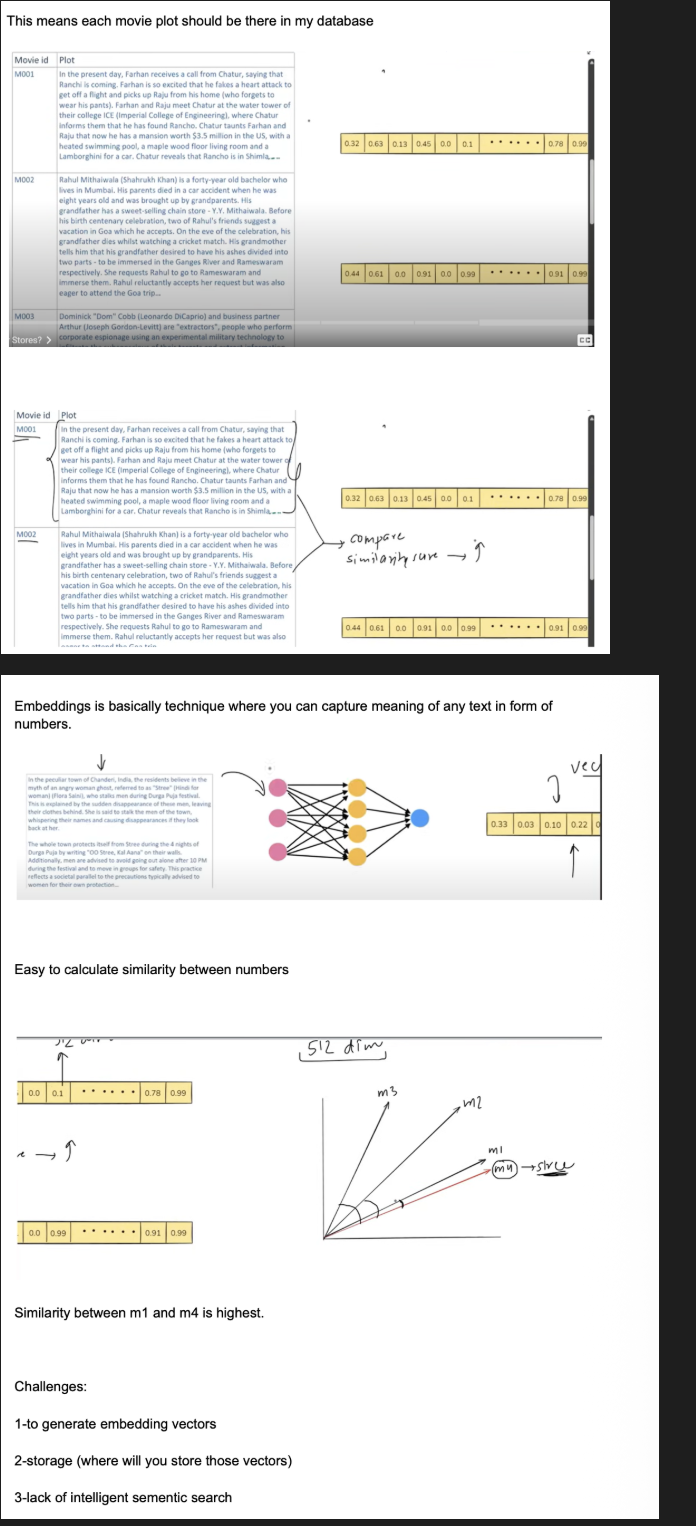

We do not store embedding vectors in relational databases like mysql or oracle bcz you cannot cal
similarity if you store it in mysql database as it does not provide this functionality

If you want to find top 5 movies similar to M001 and you have 10 lakh embeddings then you calculate dot product with all vectors and choose top 5 highest dot products.(computationally expensive) application becomes slow. We want to with very less no of comparison and I want to find top 5 movies. All three challenges are solved by VECTOR STORE

## This is where Vector Stores come in

Suppose you have 1 million movies.

You create an embedding for each movie.

Conceptually:

1. Movie 1 → [0.12, 0.45, -0.21, ...]
2. Movie 2 → [0.82, -0.14, 0.37, ...]
3. Movie 3 → [0.11, 0.42, -0.18, ...]

...

Movie 1,000,000 → [...]

You need somewhere to store these vectors and search them efficiently. That's the job of a Vector Store / Vector Database.

Movie Data -> Embedding Model -> Vectors -> Vector Store

## What does Vector Store store ?

A vector store typically stores something conceptually like:

Vector + Original content/plot + Metadata


For example:

Vector: [0.12, 0.43, -0.72, ...]


Content: "Movie about a young wizard attending a magical school..."


Metadata:

{
    "movie": "Harry Potter",

    "genre": "Fantasy",

    "year": 2001
    
}

So the vector isn't usually stored completely independently from the movie information. The metadata/content allows you to identify the movie after finding a similar vector.

## What is a VectorStore:

A vector store is a system designed to store and retrieve data represented as numerical vectors.

***Key Features***

1. Storage: Ensures that vectors and their associated metadata are retained, whether in memory for quick lookups or on disk for durability and large scale. If we store the data in RAM, it means if we close the applicationn then the data will vanish, If we store it in hard drive then data will persist.

2. Similarity Search: Helps retrieve vectors that are most similar to a query vector

3. Indexing: Provides a data structure or method that enables fast similarity searches on high-dimensional vectors (eg. nearest neighbour lookups)

4. CRUD operations: We can manage lifecycle of data, ex we can add new vectors, reading them, updating exisiting entries, removing Outdataed vectors 

## Use cases:

- RAG
- Sementic Search
- Recommendation system
- Image/Multimedia search

Traditional database search might look like:

SELECT * FROM movies WHERE genre = 'Action';

That's an exact/filter-based operation.

Vector search instead asks something like: "Find the vectors closest to this movie's vector."

Conceptually: Query vector -> Vector Store -> Similarity calculation -> nearest vectors

This is usually called similarity search or nearest-neighbor search.

## Indexing in Vector Store

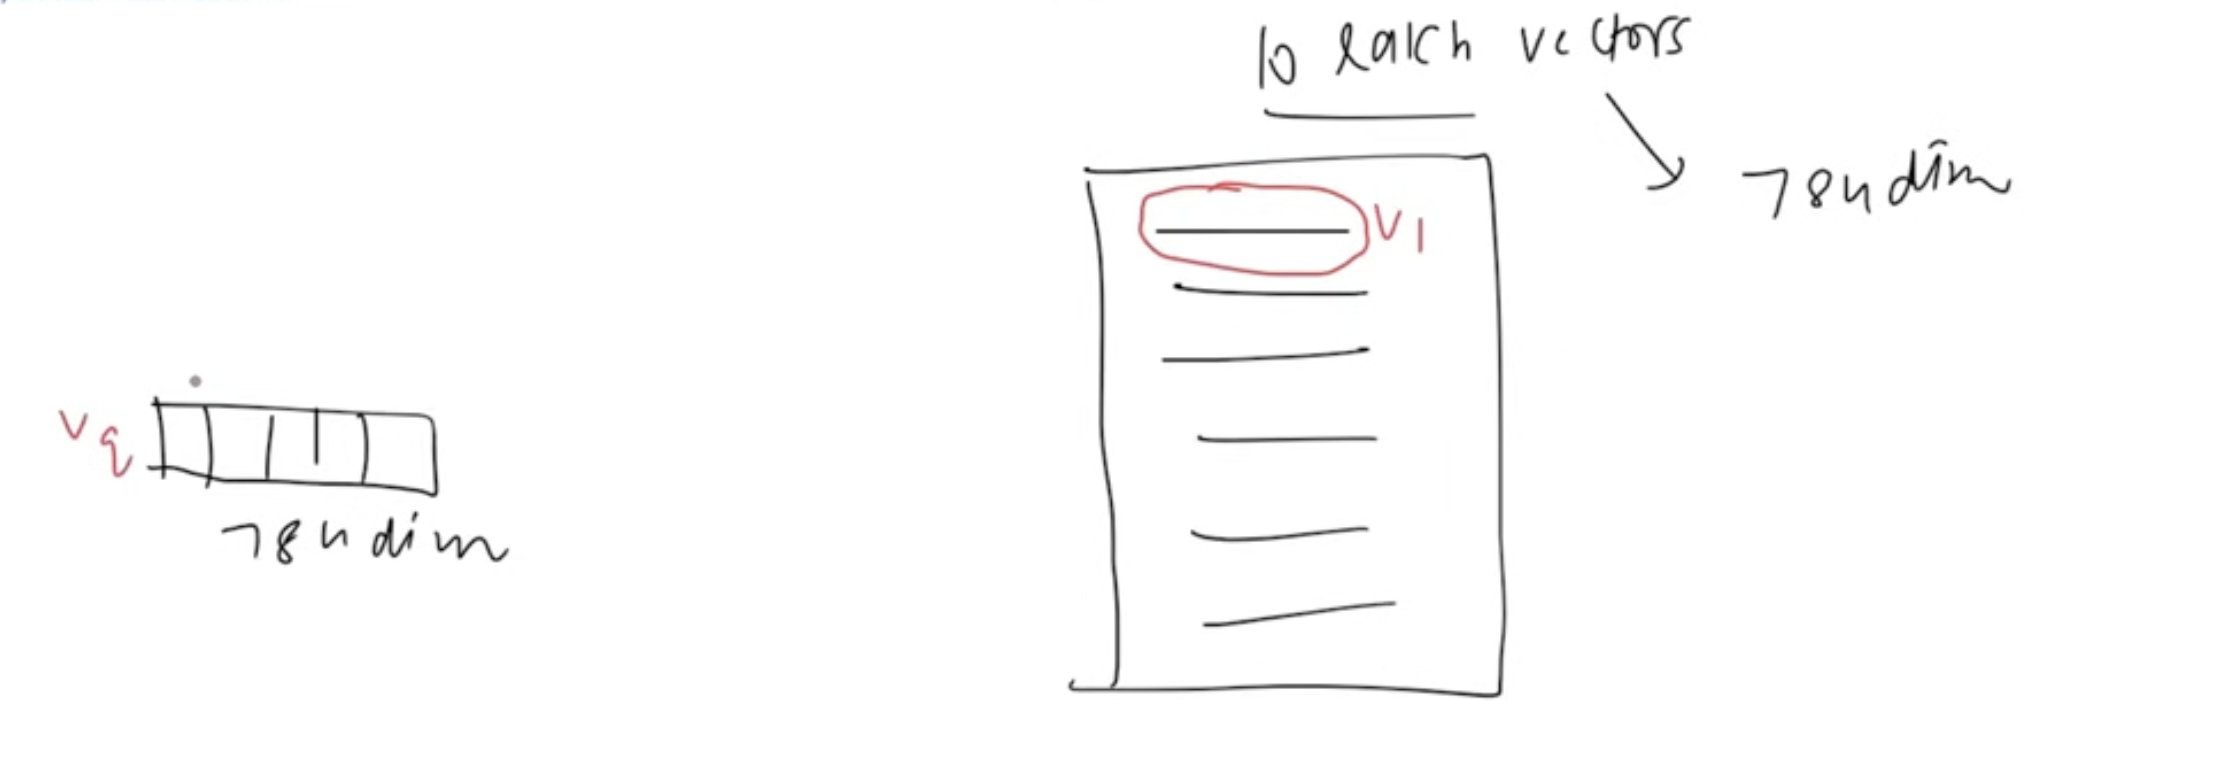

If I have 10 lakh (1 million) vectors, I don't want to compare my query vector against all 10 lakh vectors every time.

Vector 1 → [x₁, x₂, x₃, ..., x₇₈₄]

Vector 2 → [x₁, x₂, x₃, ..., x₇₈₄]

Vector 3 → [x₁, x₂, x₃, ..., x₇₈₄]

...

Vector 1,000,000 → [x₁, x₂, ..., x₇₈₄]

Now suppose the user gives a query: Query vector = Vq

Find the vector among these 10 lakh vectors that is most similar to Vq.

## The naive approach

Query vector -> Compare with Vector 1 then Compare with Vector 2 then Compare with Vector 3 and so on till Compare with Vector 1,000,000 -> find highest similarity


In [1]:
# similarity(Vq, V1)
# similarity(Vq, V2)
# similarity(Vq, V3)
# ...
# similarity(Vq, V1000000)

# Then
# max(similarity)

## Time complexity- O(N) where N=no of vectors

## USE HELP OF INDEXING (WE USE CLUSTERING ALGO)


Instead of searching the entire vector database, organize the vectors into groups and search only the relevant group(s). This is the fundamental idea behind approximate nearest-neighbor indexing techniques.

Spse 10 clusters are formed and each cluster has 1 Lakh vector. I calculate centroid of each cluster (average of all the points in a cluster)

I have 10 centroid vectors, As soon as new query vector is found, I find similarity of Vq with 10 centroid vectors and try to find which centroid vector has highest similarity with the Vq.

Lets say Vq has most similarity with Centroid 3 (C3) So i will ignore other clusters and focus only on cluster 3. 

In total we do (1 Lakh + 10 comparisons)

This is indexing

Time complexity- O( (N/n) + n) where N=total vectors and n=Total clusters

## Vector Store Vs Vector Database

A vector database is essentially a vector store plus additional database capabilities.

## Vector Store

Vector store is a lightweight library or service that focuses on:

1. vectors storing 
2. sementic similarity search

It may not provide all the features you expect from a full database system.

Vector store may not include traditional database features like role based access control, transaction etc

For example, it might have limited:

- transactions
- authentication
- distributed architecture
- backup/restore
- advanced security
- concurrency management

Examples of Vector stores:

1. FAISS
2. Chroma
3. Qdrant etc.

A lightweight vector store might be perfectly fine for:

- Prototype
- Small project
- Local development
- Experimentation

In FAISS, You can store vectors and can query them by similarity but you handle persistance and scaling separately

## Vector Database:

A full fledged database system designed to store and query vectors. A vector database provides vector search plus database-like infrastructure.

It offers additional database like features:

- Distributed architecture for horizontal scaling

You can distribute data/work across multiple machines.

In [ ]:
#               Vector DB
#                     ↓
#         ┌───────────┼───────────┐
#         ↓           ↓           ↓
#       Server      Server      Server

# This becomes important when the amount of data is huge.

- Backup and Restore : Database -> backup -> storage

You can make backups and recover data if something goes wrong. If the database crashes or data is lost, you can restore it.

- Transactions:

Database systems can provide transactional behavior. For example, if you're updating multiple pieces of data, you may want the operation to either:

Everything succeeds or Everything rolls back rather than leaving the database in an inconsistent state.

- Concurrency control

Suppose 1,000 users are accessing your application simultaneously.

The database needs mechanisms to handle concurrent operations safely.


In [ ]:

# User 1 ─┐
# User 2 ─┤
# User 3 ─┼──→ Vector Database
# User 4 ─┤
# User 5 ─┘

- Authentication and authorization:

A production database needs to control: Who is allowed to access what?

For example:

1. Admin → Read + Write
2. Developer → Read
3. User → Search only

when you have: Millions/billions of vectors + Thousands of users + Production workloads

you may want a proper vector database with infrastructure for:

- Scaling
- Reliability
- Security
- Backups
- Concurrency
- Distributed operation

vector databases such as:

- Milvus
- Qdrant
- Weaviate
- Pinecone


There is an important nuance here: The terminology isn't perfectly strict across the industry.

Some products can function as both a vector store and a more complete vector database depending on how they're deployed and what features you use.

So don't memorize:

FAISS = ONLY vector store and Qdrant = ONLY vector database as an absolute rule.

Note: Every Vector Database is a Vector Store but opposite is not True. 


## Vector Stores implementation in LangChain

We will see how langchain makes different vector stores look similar to your code, Different vector stores have different internal implementations, but LangChain gives them a common interface/API.

These are different technologies for storing/searching vectors. Without LangChain, each one may have its own API.

Conceptually:

In [ ]:
# Your Application
#        │
#        ├── FAISS API
#        ├── Chroma API
#        ├── Pinecone API
#        ├── Qdrant API
#        └── Weaviate API

# That would make your application code tightly coupled to whichever vector store you chose.

## LangChain provides wrappers:

LangChain creates integrations/wrappers around these vector stores.

In [ ]:
    #                 LangChain
    #                    │
    #       ┌────────────┼────────────┐
    #       ↓            ↓            ↓
    #     FAISS        Chroma      Pinecone
    #    Wrapper       Wrapper      Wrapper
    #       ↓            ↓            ↓
    #     FAISS        Chroma      Pinecone

# The wrapper acts as an adapter between your LangChain application and the actual vector store.
# So your application doesn't need to know every internal detail of FAISS, Chroma, Pinecone, etc.

3. The important idea: Common Interface

A uniform Vector Store API lets you swap out one backend for another with minimal code changes.

In [ ]:
## suppose you use Chroma

vector_store=Chroma(..)

# Later you decide to use FIASS instead , application logic remain similar

vector_store=FIASS(..)

### there are some common methods which remain conceptually same for all the vector stores

#1. add documents

vector_store.add_documents(...)


#2. Sementic Search

vector_store.similarity_search(...)

All the famous vector stores that exist you will find wrappers around all of them in the
langchain. These wrappers are developed in such a way that all these wrappers from different vector stores share the same method signatures

Same methods signatures:

1. add_documents()
2. add_texts()
3. from_documents()
4. from_texts()
5. similarity_search(query,k=..)

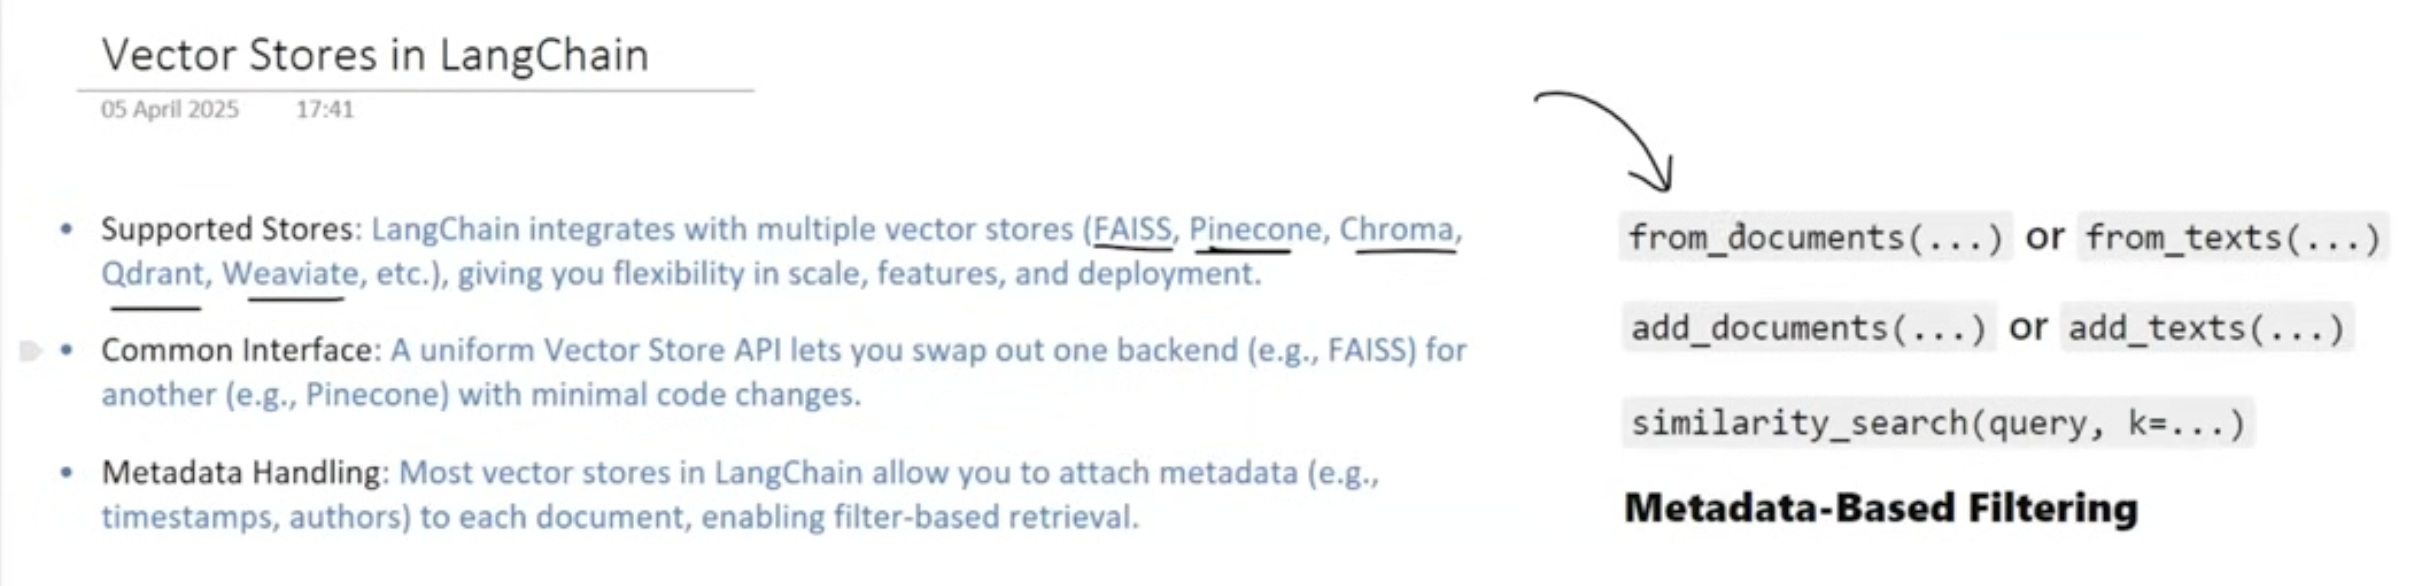

# 1. from_documents():

Create a vector store using LangChain Documents.

Documents -> Embedding Model -> Vectors -> Chroma

In [4]:
!pip install chromadb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 4.1 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 4.2 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: aiohttp╸━━━━━━━━━ 14/21 [opentelemetry-exporter-otlp-proto-common]
    Found existing installation: aiohttp 3.13.2━━━ 14/21 [opentelemetry-exporter-otlp-proto-common]
    Uninstalling aiohttp-3.13.2:━━━━━━━━━ 14/21 [opentelemetry-exporter-otlp-proto-common]
      Successfully uninstalled aiohttp-3.13.2━━━━━ 14/21 [opentelemetry-exporter-otlp-proto-common]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [chromadb]/21 [chromadb]s]ry-sdk]common]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.25.0 requires wrapt<2.0.0,>=1.10.10, but you have wrapt 2.3.0 which is incompatible.


In [5]:
# suppose you already have langchain document objects.

from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
docs=[
    Document(page_content="Python is a programming language.",metadata={"source": "python.txt"}),
    Document(page_content="Machine learning learns patterns from data.",metadata={"source": "ml.txt"})
]
from langchain_huggingface import HuggingFaceEmbeddings
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

# You can create a vector store from these documents:

vector_store=Chroma.from_documents(documents=docs,embedding=embedding_model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 2. from_texts()

Create a vector store using list of strings

Raw Text -> Embedding Model -> Vectors -> Vector Store

In [ ]:
texts = [
    "Python is a programming language.",
    "Machine learning learns patterns from data."
]

from langchain_community.vectorstores import Chroma

vector_store=Chroma.from_texts(texts=texts,embedding=embedding_model)

# 3. add_documents()

Used when you've already created your vector store

In [ ]:
docs=[
    Document(page_content="Python is a programming language.",metadata={"source": "python.txt"}),
    Document(page_content="Machine learning learns patterns from data.",metadata={"source": "ml.txt"})
]
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vector_store=vector_store.add_documents(docs,embedding=embedding_model)

new_docs = [Document(page_content="Deep learning uses neural networks.",metadata={"source": "dl.txt"})]

vector_store.add_documents(new_docs)


Existing Vector Store + New Documents -> Embeddings -> Added to Vector store

# 4.add_texts()

In [6]:
vector_store.add_texts([
    "Transformers are widely used in NLP."
])

['bb2ed916-1fd7-437f-b874-8486bd93736e']

## Chroma Vector Store

Chroma Vector Store is a lightweight Vector database that is especially friendly for local development and small to medium scale production needs.

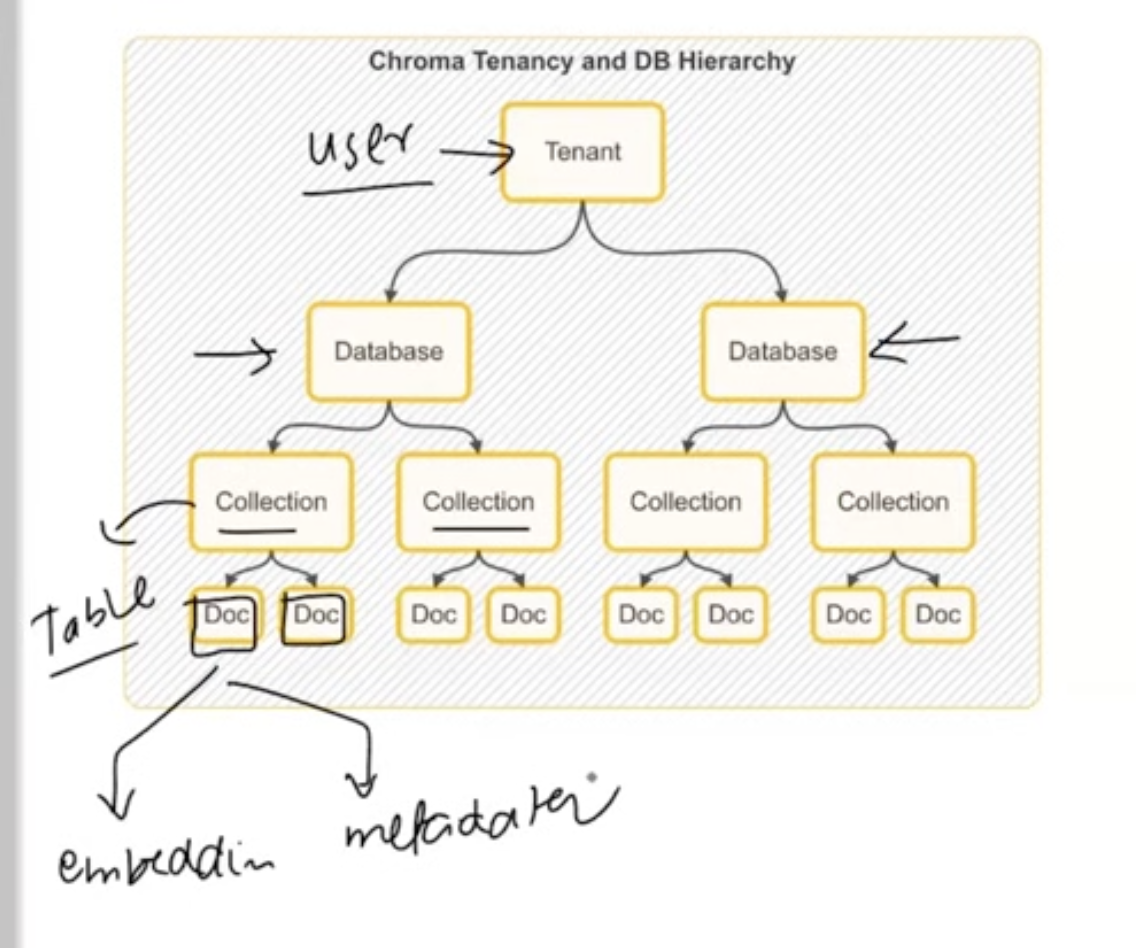

Chroma comes between Vector store and Vector database. It is not full fledged database because it is lightweight and has database features. 

Doc = embedding + metadata

Collection = Table (like in RDBMS)

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

embedding_model=HuggingFaceEmbeddings(model='sentence-transformers/all-MiniLM-L6-v2')
doc1= Document(page_content='Virat Kohli is one of the most successful and cosistent batsman in IPL history. Known for his aggressive batting style',
               metadata={'team':'Royal Challengers Bangalore'})

doc2= Document(page_content='Rohit Sharma is the most successful captain in the IPL history, leading Mumbai Indians to five titles. He is known for his sixes',
               metadata={'team':'Mumbai Indians'})

doc3 = Document(
    page_content="MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicket are insanely good",
    metadata={"team": "Chennai Super Kings"}
)

doc4 = Document(
    page_content="Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his killer balling",
    metadata={"team": "Mumbai Indians"}
)

doc5 = Document(
    page_content="Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his wit and intellegence helps a lot.",
    metadata={"team": "Chennai Super Kings"}
)

docs=[doc1,doc2,doc3,doc4,doc5]
## Create a Vector Store
vector_store= Chroma(embedding_function=embedding_model,
                     persist_directory='chroma-db',  ## we store it in a folder named chrom-db
                     collection_name='sample'
                     )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_63565/1204304150.py:29: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store= Chroma(embedding_function=embedding_model,


In [ ]:
## Add Documents

vector_store.add_documents(docs)

## Every document has been assigned an unique Id so that we can retrieve it later

['03341b2f-c6c7-47ac-a8bc-5bf8f289e6f4',
 '570af27e-991f-483f-ba41-4835b2fa6091',
 'a042663a-be06-44bd-836c-2f6407c94da4',
 'd01d7df0-27d0-4f00-b7e2-c2499d8f48fb',
 '48451824-588e-4ddd-8a28-57f44e14830d']

In [10]:
## View Documents

vector_store.get(include=['documents','embeddings','metadatas'])

{'ids': ['03341b2f-c6c7-47ac-a8bc-5bf8f289e6f4',
  '570af27e-991f-483f-ba41-4835b2fa6091',
  'a042663a-be06-44bd-836c-2f6407c94da4',
  'd01d7df0-27d0-4f00-b7e2-c2499d8f48fb',
  '48451824-588e-4ddd-8a28-57f44e14830d'],
 'embeddings': array([[ 0.02707441,  0.08666241, -0.06754301, ..., -0.03578476,
          0.03479655,  0.04241433],
        [-0.01135069,  0.00193181, -0.04078059, ..., -0.01840882,
         -0.00972345,  0.03694724],
        [-0.07464959,  0.00511695,  0.02443986, ..., -0.03109185,
         -0.07522483, -0.00048174],
        [ 0.01699281, -0.00601879, -0.02486039, ..., -0.08946618,
          0.00654438,  0.08618684],
        [ 0.01218027,  0.03631304, -0.03238744, ..., -0.06849656,
         -0.06684141, -0.03068449]], shape=(5, 384)),
 'documents': ['Virat Kohli is one of the most successful and cosistent batsman in IPL history. Known for his aggressive batting style',
  'Rohit Sharma is the most successful captain in the IPL history, leading Mumbai Indians to five title

In [15]:
## search documents

vector_store.similarity_search(query='Who among there are bowler?',k=1)

[Document(metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his killer balling')]

In [21]:
## search documents with similarity score

vector_store.similarity_search_with_score(query='who among are bowler?',k=2)

## Lesser the score is, the more the similarity is 
## represents the distance with the query

[(Document(metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his killer balling'),
  0.9937961101531982),
 (Document(metadata={'team': 'Royal Challengers Bangalore'}, page_content='Virat Kohli is one of the most successful and cosistent batsman in IPL history. Known for his aggressive batting style'),
  1.1044373512268066)]

In [23]:
## meta-data filtering

vector_store.similarity_search_with_score(query="",filter={'team':'Chennai Super Kings'})

[(Document(metadata={'team': 'Chennai Super Kings'}, page_content='Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his wit and intellegence helps a lot.'),
  1.8709454536437988),
 (Document(metadata={'team': 'Chennai Super Kings'}, page_content='MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicket are insanely good'),
  1.8822245597839355)]

In [25]:
vector_store.get(include=['metadatas'])

{'ids': ['03341b2f-c6c7-47ac-a8bc-5bf8f289e6f4',
  '570af27e-991f-483f-ba41-4835b2fa6091',
  'a042663a-be06-44bd-836c-2f6407c94da4',
  'd01d7df0-27d0-4f00-b7e2-c2499d8f48fb',
  '48451824-588e-4ddd-8a28-57f44e14830d'],
 'embeddings': None,
 'documents': None,
 'uris': None,
 'included': ['metadatas'],
 'data': None,
 'metadatas': [{'team': 'Royal Challengers Bangalore'},
  {'team': 'Mumbai Indians'},
  {'team': 'Chennai Super Kings'},
  {'team': 'Mumbai Indians'},
  {'team': 'Chennai Super Kings'}]}

In [27]:
## Update Documents

updated_doc1=Document(page_content='Virat Kohli, the former captain of Royal Challengers Bangalore is renowned for his aggressive leadership and consistency in batting. He has received orange cap',
                      metadata={'team':'Royal Challangers Bangalore'})
## we will paste virat kohli document id below which we copied
vector_store.update_document(document_id='03341b2f-c6c7-47ac-a8bc-5bf8f289e6f4',document=updated_doc1)

In [28]:
vector_store.get(include=['metadatas','embeddings','documents'])

{'ids': ['03341b2f-c6c7-47ac-a8bc-5bf8f289e6f4',
  '570af27e-991f-483f-ba41-4835b2fa6091',
  'a042663a-be06-44bd-836c-2f6407c94da4',
  'd01d7df0-27d0-4f00-b7e2-c2499d8f48fb',
  '48451824-588e-4ddd-8a28-57f44e14830d'],
 'embeddings': array([[ 0.01964021,  0.07372725, -0.05631452, ..., -0.07867017,
          0.0163934 , -0.00234901],
        [-0.01135069,  0.00193181, -0.04078059, ..., -0.01840882,
         -0.00972345,  0.03694724],
        [-0.07464959,  0.00511695,  0.02443986, ..., -0.03109185,
         -0.07522483, -0.00048174],
        [ 0.01699281, -0.00601879, -0.02486039, ..., -0.08946618,
          0.00654438,  0.08618684],
        [ 0.01218027,  0.03631304, -0.03238744, ..., -0.06849656,
         -0.06684141, -0.03068449]], shape=(5, 384)),
 'documents': ['Virat Kohli, the former captain of Royal Challengers Bangalore is renowned for his aggressive leadership and consistency in batting. He has received orange cap',
  'Rohit Sharma is the most successful captain in the IPL hist

In [29]:
## delete documents

vector_store.delete(ids=['03341b2f-c6c7-47ac-a8bc-5bf8f289e6f4'])

In [30]:
vector_store.get(include=['metadatas','embeddings','documents'])

{'ids': ['570af27e-991f-483f-ba41-4835b2fa6091',
  'a042663a-be06-44bd-836c-2f6407c94da4',
  'd01d7df0-27d0-4f00-b7e2-c2499d8f48fb',
  '48451824-588e-4ddd-8a28-57f44e14830d'],
 'embeddings': array([[-0.01135069,  0.00193181, -0.04078059, ..., -0.01840882,
         -0.00972345,  0.03694724],
        [-0.07464959,  0.00511695,  0.02443986, ..., -0.03109185,
         -0.07522483, -0.00048174],
        [ 0.01699281, -0.00601879, -0.02486039, ..., -0.08946618,
          0.00654438,  0.08618684],
        [ 0.01218027,  0.03631304, -0.03238744, ..., -0.06849656,
         -0.06684141, -0.03068449]], shape=(4, 384)),
 'documents': ['Rohit Sharma is the most successful captain in the IPL history, leading Mumbai Indians to five titles. He is known for his sixes',
  'MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicket are insanely good',
  'Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mu

In [34]:
from langchain_community.vectorstores import FAISS,EcloudESVectorStore,TablestoreVectorStore,UpstashVectorStore,InfinispanVS,OpenSearchVectorSearch,ZepCloudVectorStore,Vald,Bagel,NeuralDBClientVectorStore,ManticoreSearch
